In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error, r2_score

In [2]:
sns.set_theme(style="whitegrid")

RANDOM_STATE = 42

dataset = pd.read_excel("HousePricePrediction.xlsx")

## Очистка данных

1. Удаление колонки id, поскольку она не дает полезной информации для модели.
2. Заполнение пропусков средним значением в целевой колонке SalesPrice.
3. Удаление остальных строк с пропусками.

In [ ]:
if "Id" in dataset.columns:
    dataset = dataset.drop("Id", axis=1)

# Заполнение пропусков средним значением в столбце SalePrice
dataset["SalePrice"] = dataset["SalePrice"].fillna(dataset["SalePrice"].mean())

# Удаление строк с пропущенными значениями
dataset = dataset.dropna()

# Проверка на наличие пропусков после удаления строк с пропусками
dataset.isnull().sum()

MSSubClass      0
MSZoning        0
LotArea         0
LotConfig       0
BldgType        0
OverallCond     0
YearBuilt       0
YearRemodAdd    0
Exterior1st     0
BsmtFinSF2      0
TotalBsmtSF     0
SalePrice       0
dtype: int64

## Преобразование категориальных признаков в числовые через One-Hot Encoding

OHE создает новые подкатегориальные колонки из исходных, содержащие значения 1/0, означающие наличие/отсутствие данного признака

In [ ]:
obj_cols = dataset.select_dtypes(include=["object"]).columns.tolist()

ohe = OneHotEncoder(
    sparse_output=False,
    handle_unknown="ignore"
)

# fit transform превращает данные в числовую матрицу из 1/0
ohe_arr = ohe.fit_transform(dataset[obj_cols])


# Превращаем numpy arr обратно в dataframe 
ohe_cols = pd.DataFrame(
    ohe_arr,
    columns=ohe.get_feature_names_out(obj_cols),
    index=dataset.index,
)

#Удаляем исходные текстовые колонки из таблицы
num_part = dataset.drop(obj_cols, axis=1)

#Объединяем исходные числовые признаки с новыми 
df_final = pd.concat([num_part, ohe_cols], axis=1)

df_final.head()


['MSZoning', 'LotConfig', 'BldgType', 'Exterior1st']


,MSSubClass,LotArea,OverallCond,YearBuilt,YearRemodAdd,BsmtFinSF2,TotalBsmtSF,SalePrice,MSZoning_C (all),MSZoning_FV,...,Exterior1st_CemntBd,Exterior1st_HdBoard,Exterior1st_ImStucc,Exterior1st_MetalSd,Exterior1st_Plywood,Exterior1st_Stone,Exterior1st_Stucco,Exterior1st_VinylSd,Exterior1st_Wd Sdng,Exterior1st_WdShing
0,60,8450,5,2003,2003,0.0,856.0,208500.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,20,9600,8,1976,1976,0.0,1262.0,181500.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,60,11250,5,2001,2002,0.0,920.0,223500.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,70,9550,5,1915,1970,0.0,756.0,140000.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,60,14260,5,2000,2000,0.0,1145.0,250000.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


## Разделение на X и y, train и test

В обучении с учителем есть:
- X - признаки, по которым модель делает предсказание/ классификацию;
- y - target, правильный ответ.

В нашем случае target это SalePrice.

Разделение выборки на train/test будет в соотношении 80/20.

In [5]:
# Игнорируем SalePrice, т.к. настройка весов модели происходит относительно других признаков.
X = df_final.drop("SalePrice", axis=1)

# у содержит только целевую переменную SalePrice для каждого объекта.
y = df_final["SalePrice"]

X_train, X_test, y_train, y_test = train_test_split(
    X,                          # признаки
    y,                          # целевая переменная
    train_size=0.8,
    test_size=0.2,
    random_state=RANDOM_STATE   # фиксированное значения для воспроизводимости
)


# Размеры получившихся частей.
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (2330, 37)
X_test: (583, 37)
y_train: (2330,)
y_test: (583,)


## Обучение моделей

Сравним три регрессионные модели:

1. `SVR` - Support Vector Regression.
2. `RandomForestRegressor` - ансамбль деревьев.
3. `LinearRegression` - линейная модель.

Для оценки результатов предсказаний используем:

- `MAPE`: средняя процентная ошибка. Чем меньше, тем лучше.
- `MAE`: средняя абсолютная ошибка. Чем меньше, тем лучше.
- `RMSE`: корень средней квадратичной ошибки. Больше штрафует большие ошибки. Чем меньше, тем лучше.
- <code>R<sup>2</sup></code> - доля объясненной вариации. Чем больше, тем лучше.


In [ ]:
# Словарь с моделями, чтобы проверить каждую в цикле.
models = {
    "SVR": SVR(), 
    "RandomForestRegressor": RandomForestRegressor(),
    "LinearRegression": LinearRegression(),
}

# Список для хранения метрик каждой модели
results = []

# Проходим по всем моделям через цикл.
for model_name, model in models.items():

    # fit обучает модель на train данных.
    model.fit(X_train, y_train)

    # predict предсказывает на тестовой выборке.
    y_pred = model.predict(X_test)

    # Далее сохраняем значения метрик.
    mape = mean_absolute_percentage_error(y_test, y_pred)
    
    mae = mean_absolute_error(y_test, y_pred)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    r2 = r2_score(y_test, y_pred)

    # Добавляем результаты в список results
    results.append({
        "model": model_name,
        "MAPE": mape,
        "MAE": mae,
        "RMSE": rmse, 
        "R2": r2,
    })

# Конвертируем список results в dataframe и сортируем по значениям MAPE
results_df = pd.DataFrame(results).sort_values("MAPE")

results_df


,model,MAPE,MAE,RMSE,R2
2,LinearRegression,0.200235,32690.891525,48798.731391,0.346881
1,RandomForestRegressor,0.204190,32742.778749,46765.116631,0.400182
0,SVR,0.206865,31300.120089,60411.148185,-0.000943


Как видно из таблицы, линейная регрессия по метрике MAPE дает лучший результат прогнозирования.

## Визуализация качества лучшей модели по метрике MAPE

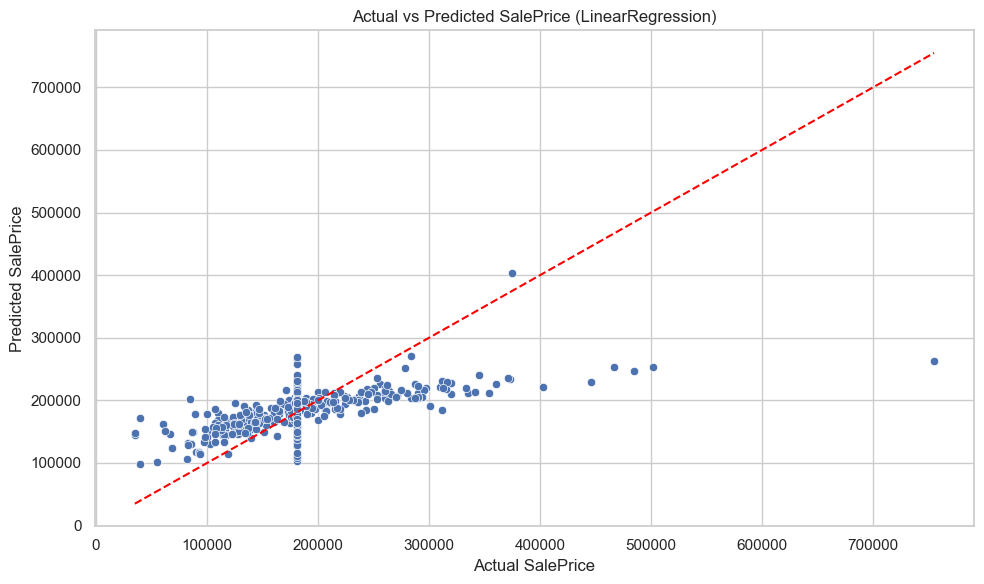

In [7]:
# Выбираем лучшую модель по MAPE
best_model_name = results_df.iloc[0]["model"]

# Получаем объект лучшей модели из словаря models
best_model = models[best_model_name]

# Предсказываем значения с помощью лучшей модели
best_pred = best_model.predict(X_test)

# Строим график
plt.figure(figsize=(10, 6))

sns.scatterplot(x=y_test, y=best_pred)

min_val = min(y_test.min(), best_pred.min())
max_val = max(y_test.max(), best_pred.max())

plt.plot([min_val, max_val], [min_val, max_val], color="red", linestyle="--")

plt.title(f"Actual vs Predicted SalePrice ({best_model_name})")

plt.xlabel("Actual SalePrice")
plt.ylabel("Predicted SalePrice")

plt.tight_layout()

plt.show()
